# Graph를 이용한 정보 검색

In [ ]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
print(AZURE_OPENAI_API_KEY[:10])
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'true' #true, false    
os.environ['LANGCHAIN_PROJECT'] = 'RAG'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    if len(os.getenv('LANGCHAIN_API_KEY')) > 0:
        print('랭스미스로 추적 중입니다 :', os.getenv('LANGSMITH_API_KEY')[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

43b13g4OZS
gpt-5-mini
랭스미스로 추적 중입니다 : lsv2_pt_24


In [ ]:
# %pip install graph-rag-example-helpers langchain-graph-retriever 
# uv add --native-tls graph-rag-example-helpers langchain-graph-retriever

In [5]:
from langchain_openai import AzureOpenAIEmbeddings

emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)

Graph RAG 예제용 “동물(animals)” 데이터셋을 로드합니다.

이 데이터셋은 각 문서가 짧은 텍스트(예: 동물의 특징, 서식지, 먹이 등)를 담고 있습니다.

아래 링크에 가면 데이터셋에 대한 간단한 설명이 있습니다.

https://datastax.github.io/graph-rag/reference/graph_rag_example_helpers/

이 데이터는 graphRAG를 위해 이미 전처리된 Document입니다.

id에는 해당 동물의 이름이 명시되어 있고 metadata에 각각의 속성들이 있어 이 metadata가 지식 그래프 역할을 합니다.

실제 문장은 page_content에 들어있습니다.

In [7]:
from graph_rag_example_helpers.datasets.animals import fetch_documents
from langchain_community.vectorstores.utils import filter_complex_metadata
from langchain_graph_retriever.transformers import ShreddingTransformer

raw_docs = fetch_documents()


print(f"데이터 수 : {len(raw_docs)}")
raw_docs[:10]

SSLError: HTTPSConnectionPool(host='raw.githubusercontent.com', port=443): Max retries exceeded with url: /datastax/graph-rag/refs/heads/main/data/animals.jsonl (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)')))

"the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants"     
(주머니쥐는 굴을 파는 습관과 개미를 냄새 맡는 데 사용되는 긴 주둥이로 유명한 야행성 포유류입니다.)

이 문장에서 **문서의 메인 ID(aardvark)**는 중심 개체(노드)를 나타내며,     
**메타데이터(metadata)**에는 그 개체가 가진 **속성**과 **관계**가 적혀있습니다.

즉, ID와 메타데이터는 문장을 그래프로 변환하기 위한 구조적 관계 정보 역할을 하고 이 정보를 기반으로 GraphRAG은     
"aardvark → nocturnal", "aardvark → burrowing", "aardvark → ants" 와 같은 노드 간 연결(엣지)을 자동으로 구성합니다.


ShreddingTransformer는 문서 메타데이터를 “분해(Shredding)”하는 역할을 합니다. 

원래 A와 B가 A(key):B(value)로 되어있었다면 이걸 모두 키로 옮겨 A->B:§로 변경시킵니다. 

> §는 transformer가 변경시키면서 기존 value에 있던 위치에 넣는 특수 토큰으로 특별한 의미는 없습니다.

예시)

id = aardvark, metadata = {keywords': ['burrowing', 'nocturnal', 'ants', 'savanna']}라면 지식그래프에서  ""aardvark_node ---> burrowing, aardvark_node ---> nocturnal,"" 이렇게 연결되어야 하기 때문에

'keywords→"burrowing"': '§' 이런식으로 모든 리스트를 분해하여 평탄화 시킵니다.


In [ ]:
raw_docs = fetch_documents()
print(f"raw_docs >>".ljust(15), raw_docs[0])

docs = ShreddingTransformer().transform_documents(raw_docs)
print(f"docs >>".ljust(15), docs[0])

animal_docs = filter_complex_metadata(docs) #str, int, float, bool 타입이 아닌 데이터는 제거
print(f"animal_docs >>".ljust(15), animal_docs[0])

raw_docs >>     page_content='the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords': ['burrowing', 'nocturnal', 'ants', 'savanna'], 'habitat': 'savanna', 'tags': [{'a': 5, 'b': 7}, {'a': 8, 'b': 10}]}
docs >>         page_content='the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords→"burrowing"': '§', 'keywords→"nocturnal"': '§', 'keywords→"ants"': '§', 'keywords→"savanna"': '§', 'habitat': 'savanna', 'tags→{"a": 5, "b": 7}': '§', 'tags→{"a": 8, "b": 10}': '§', '__shredded_keys': '["keywords", "tags"]'}
animal_docs >>  page_content='the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords→"burrowing"': '§', 'keywords→"nocturnal"': '§', 'keywords→"ants"': '§', 

In [5]:
# 일반적인 벡터 리트리버
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore.from_documents(
    documents=animal_docs,
    embedding=emb,
)

for data in vector_store.similarity_search("카피바라 근처에서는 어떤 동물을 볼 수 있나요?", k=8):
    print(data)

page_content='caribou, also known as reindeer, are migratory mammals found in arctic regions.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords→"migratory"': '§', 'keywords→"arctic"': '§', 'keywords→"herbivore"': '§', 'keywords→"tundra"': '§', 'diet': 'herbivorous', '__shredded_keys': '["keywords"]'}
page_content='bears are large mammals that can be found across many habitats, from forests to tundras.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords→"large"': '§', 'keywords→"habitat"': '§', 'keywords→"omnivore"': '§', 'keywords→"forest-floor"': '§', 'diet': 'omnivorous', 'habitat': 'tundra', '__shredded_keys': '["keywords"]'}
page_content='antelopes are graceful herbivorous mammals that are often prey for large predators in the wild.' metadata={'type': 'mammal', 'number_of_legs': 4, 'keywords→"graceful"': '§', 'keywords→"herbivore"': '§', 'keywords→"prey"': '§', 'habitat': 'grasslands', '__shredded_keys': '["keywords"]'}
page_content='coyotes are adaptable mammals 

## GraphRetriever를 사용해 그래프 검색하기 

GraphRetriever는 단순히 의미 유사도(similarity_search)로 검색하는 대신,

“엔티티의 속성(노드)과 관계(엣지)를 따라가며 정보 검색” 을 수행하는 그래프형 RAG 리트리버(retriever)입니다

가장 중요한건 edges로 어떤 속성끼리 엣지로 연결할지를 결정할 수 있습니다. 즉 내가 선택한 특성으로 그래프를 연결해 노드를 추출할 수 있습니다.

max_depth는 hop이라는 용어로 설명하는데 해당 노드로부터 몇 단계 건너서까지 검색하는지를 결정합니다.

- max_depth = 0 → 자기 자신만
- max_depth = 1 → 바로 연결된 이웃만
- max_depth = 2 → 이웃의 이웃까지


In [6]:
from graph_retriever.strategies import Eager
from langchain_graph_retriever import GraphRetriever

traversal_retriever = GraphRetriever(
    store = vector_store, #일반 벡터 스토어(리트리버)를 사용합니다.
    edges = [("type", "type"), ("habitat", "habitat"), ("number_of_legs", "number_of_legs"), ("diet", "diet"), ("origin", "origin")],
    strategy = Eager(k=8, start_k=15, max_depth=2),  #처음에 15개를 검색하고 그 중 리랭크를 적용해 8개를 최종 결과로 반환합니다.
)

for doc in traversal_retriever.invoke("카피바라 근처에서는 어떤 동물을 볼 수 있나요?"):
    print(doc)

page_content='caribou, also known as reindeer, are migratory mammals found in arctic regions.' metadata={'_depth': 0, '_similarity_score': np.float64(0.3173553356286306), 'type': 'mammal', 'number_of_legs': 4, 'keywords→"migratory"': '§', 'keywords→"arctic"': '§', 'keywords→"herbivore"': '§', 'keywords→"tundra"': '§', 'diet': 'herbivorous', '__shredded_keys': '["keywords"]'}
page_content='bears are large mammals that can be found across many habitats, from forests to tundras.' metadata={'_depth': 0, '_similarity_score': np.float64(0.31121238239105287), 'type': 'mammal', 'number_of_legs': 4, 'keywords→"large"': '§', 'keywords→"habitat"': '§', 'keywords→"omnivore"': '§', 'keywords→"forest-floor"': '§', 'diet': 'omnivorous', 'habitat': 'tundra', '__shredded_keys': '["keywords"]'}
page_content='antelopes are graceful herbivorous mammals that are often prey for large predators in the wild.' metadata={'_depth': 0, '_similarity_score': np.float64(0.3053647012606632), 'type': 'mammal', 'number

아래 코드는 위에서 연결한 그래프를 시각적으로 보기 위한 것으로 RAG와는 관련없고 이해를 돕기 위한 자료입니다.

{'habitat', 'number_of_legs', 'diet', 'type', 'origin'}


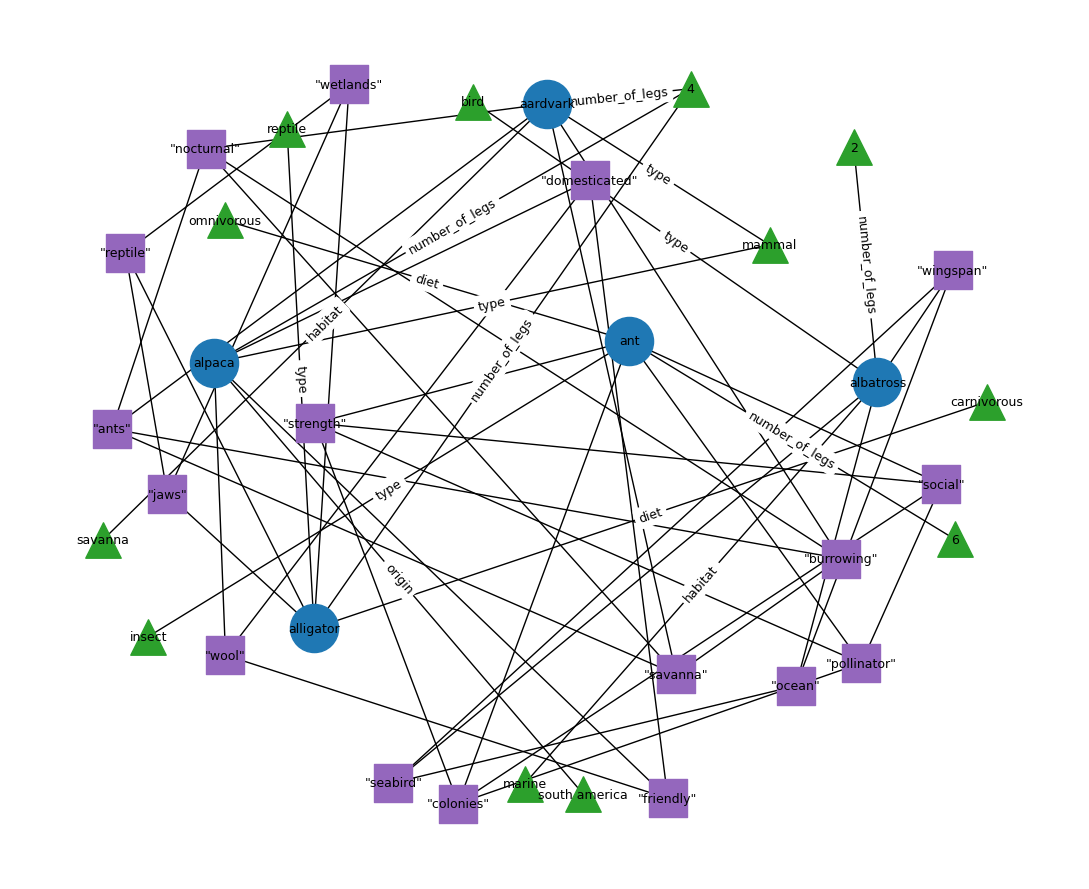

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx
def extract_keywords(md: dict):
    kws = []
    for k, v in md.items():
        if v == '§' and k.startswith('keywords→'):
            kw = k.split('→', 1)[1].strip()
            kws.append(kw.strip())
    return kws

def extract_scalar_props(md: dict):
    out = {}
    for k, v in md.items():
        if v != '§':
            out[k] = v
    return out

animal_nodes = []
keyword_nodes = set()
value_nodes = set() 
animal_keywords = {}
animal_props = {}
animal_info = set() 

for d in docs[:5]:
    aid = d.id
    animal_nodes.append(aid)
    kws = extract_keywords(d.metadata)
    props = extract_scalar_props(d.metadata)
    animal_keywords[aid] = kws
    animal_props[aid] = props
    for kw in kws:
        keyword_nodes.add(kw)
    for k, v in props.items():
        if not k.startswith('__'):
            value_nodes.add(str(v))
            animal_info.add(k)
print(animal_info)
G = nx.Graph()

for a in animal_nodes:
    G.add_node(a, kind="animal")
for kw in keyword_nodes:
    G.add_node(kw, kind="keyword")
for val in value_nodes:
    G.add_node(val, kind="value")

for a, kws in animal_keywords.items():
    for kw in kws:
        G.add_edge(a, kw, etype="has_keyword", weight=1.0)

kw_pair_weights = Counter()
for kws in animal_keywords.values():
    for u, v in combinations(sorted(set(kws)), 2):
        kw_pair_weights[(u, v)] += 1
for (u, v), w in kw_pair_weights.items():
    if u in G and v in G:
        if G.has_edge(u, v):
            G[u][v]["weight"] = G[u][v].get("weight", 0) + w
            G[u][v]["etype"] = "kw_cooccur"
        else:
            G.add_edge(u, v, etype="kw_cooccur", weight=float(w))

for a, props in animal_props.items():
    for k, v in props.items():
        if k in animal_info:
            val = str(v)
            if val in G:
                if G.has_edge(a, val):
                    prev = G[a][val].get("label", "")
                    new_label = f"{prev},{k}" if prev else k
                    G[a][val]["label"] = new_label
                else:
                    G.add_edge(a, val, etype="prop", weight=1.0, label=k)

pos = nx.spring_layout(G, seed=42, k=2)

animals = [n for n, d in G.nodes(data=True) if d.get("kind") == "animal"]
keywords = [n for n, d in G.nodes(data=True) if d.get("kind") == "keyword"]
values = [n for n, d in G.nodes(data=True) if d.get("kind") == "value"]

plt.figure(figsize=(11, 9))

nx.draw_networkx_nodes(G, pos, nodelist=animals, node_shape="o", node_size=1200, node_color="#1f78b4")
nx.draw_networkx_nodes(G, pos, nodelist=keywords, node_shape="s", node_size=750, node_color="#9467bd")
nx.draw_networkx_nodes(G, pos, nodelist=values, node_shape="^", node_size=650, node_color="#2ca02c")

edges = G.edges(data=True)
widths = [max(1.0, d.get("weight", 1.0)) for (_, _, d) in edges]
nx.draw_networkx_edges(G, pos, width=widths, arrows=False)

nx.draw_networkx_labels(G, pos, font_size=9)

edge_labels = {(u, v): d["label"] for (u, v, d) in edges if "label" in d}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.axis("off")
plt.tight_layout()
plt.show()

Exersize) graph 리트리버 옵션을 바꾸면서 결과의 변화를 보기

In [8]:
standard_retriever = GraphRetriever( 
    store = vector_store,
    edges = [("habitat", "habitat"), ("origin", "origin")], #edge 연결이나 max_depth, start_k등을 변경해가며 결과가 어떻게 변경되는지 실험해봅시다. 
    strategy = Eager(k=10, start_k=15, max_depth=0),
)
for doc in standard_retriever.invoke("카피바라 근처에서는 어떤 다른 동물을 발견할 수 있나요?"):
    print(f"{doc.id}: {doc.page_content}")

coyote: coyotes are adaptable mammals known for their distinctive howls and cunning nature.
jackal: jackals are carnivorous mammals known for their scavenging and adaptability.
caribou: caribou, also known as reindeer, are migratory mammals found in arctic regions.
bear: bears are large mammals that can be found across many habitats, from forests to tundras.
aardvark: the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants.
gazelle: gazelles are fast and agile mammals commonly found in grasslands and savannas.
capybara: capybaras are the largest rodents in the world and are highly social animals.
ferret: ferrets are small, curious mammals often kept as pets for their playful nature.
antelope: antelopes are graceful herbivorous mammals that are often prey for large predators in the wild.
elk: elk are large deer species known for their impressive antlers and bugling calls during mating season.


## Graph 리트리버를 사용하여 RAG를 만들어보기

그래프 리트리버가 이미 만들어졌기 때문에 간단하게 RAG를 만들 수 있습니다.

In [9]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
)

prompt = ChatPromptTemplate.from_template(
"""아래 컨텍스트만 근거로 문장으로 답하세요.

##컨텍스트:{context}

##질문: {question}"""
)

def format_docs(docs):
    return "\n\n".join(f"<content>{doc.page_content}</content>" for doc in docs)

chain = (
    {"context": standard_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
chain.invoke("카피바라 근처에서 발견할 수 있는 동물은 뭐야?")

'카피바라 근처에서 발견할 수 있는 동물에 대한 정보는 주어진 컨텍스트에 없습니다.'

정작 그러나 결과가 별로 좋지 않습니다. 아래 리트리버를 실행해보면 컨텐츠가 잘 검색 되었는지 의심이 됩니다.

In [10]:
result = (standard_retriever | format_docs).invoke("카피바라 근처에서 발견할 수 있는 동물은 뭐야?")
print(result)

<content>caribou, also known as reindeer, are migratory mammals found in arctic regions.</content>

<content>the aardvark is a nocturnal mammal known for its burrowing habits and long snout used to sniff out ants.</content>

<content>coyotes are adaptable mammals known for their distinctive howls and cunning nature.</content>

<content>jackals are carnivorous mammals known for their scavenging and adaptability.</content>

<content>gazelles are fast and agile mammals commonly found in grasslands and savannas.</content>

<content>capybaras are the largest rodents in the world and are highly social animals.</content>

<content>antelopes are graceful herbivorous mammals that are often prey for large predators in the wild.</content>

<content>boars are wild relatives of pigs, known for their tough hides and tusks.</content>

<content>foxes are small, agile mammals known for their cunning behavior and bushy tails.</content>

<content>badgers are burrowing mammals known for their aggressive d

영어로 질문을 해 보면 조금 더 나은 결과가 나오는 것을 볼 수 있습니다.

In [11]:
chain.invoke("what animals could be found near a capybara?")

'Capybaras are highly social animals, so other animals that are social or live in similar habitats, such as guinea pigs or possibly other rodents, could be found near them.'

아무래도 데이터가 영어로 되어있어 한글 입력에 대해 약한 성능을 보이는 것 같습니다.

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

translate_for_retrieval = ( #rewrite + translate chain  
    ChatPromptTemplate.from_template(
        """
        사용자의 질문을 RAG를 위한 검색용으로 적합한 간결한 영어 키워드로 번역하세요.
        고유명사는 그대로 유지하세요.
        번역된 질의문만 출력하세요.

        질문: {question}"""
    )
    | llm
    | StrOutputParser()
)

def format_docs(docs):
    return "\n\n".join(f"text: {d.page_content}\nmetadata: {d.metadata}" for d in docs)

chain = (
    {
        "question": RunnablePassthrough(),                                
        "context": translate_for_retrieval | standard_retriever | format_docs, 
    }
    | ChatPromptTemplate.from_template(
        """아래 컨텍스트만 근거로 문장으로 답하세요.
        
        ##컨텍스트:{context}
        
        ##질문: {question}"""
    )
    | llm
    | StrOutputParser()
)
print(translate_for_retrieval.invoke("카피바라 근처에서 발견할 수 있는 동물은 뭐야?"))
chain.invoke("카피바라 근처에서 발견할 수 있는 동물은 뭐야?")

animals near capybara


'카피바라는 습지(wetlands)에 서식하는 동물이므로, 같은 서식지에 관한 정보가 있는 동물 중에서는 특별히 언급된 동물이 없습니다. 따라서 제공된 정보만으로는 카피바라 근처에서 발견할 수 있는 구체적인 동물을 알 수 없습니다.'

## Graph Transformers, GraphQAChain를 사용해 Graph RAG 만들기

앞에서 예시를 통해 그래프의 속성이 meta data로 되어 있을 때 그것을 사용해 그래프로 변경해 그래프 리트리버를 사용하는 방법을 봤습니다.

이번에는 1) 자연어 문장으로 부터 엔티티를 추출해 metadata로 변경하는 방법과 그렇게 만들어진 graph 정보를 가지고

2) 랭체인에서 제공하는 graphQA chain을 통해 검색하는 방법을 해보겠습니다.

In [13]:
import os
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain.chains import GraphQAChain
from langchain_core.documents import Document
from langchain_community.graphs.networkx_graph import NetworkxEntityGraph

In [14]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
)

In [15]:
text = """
Marie Curie, born in 1867, was a Polish and naturalised-French physicist and chemist who conducted pioneering research on radioactivity.
She was the first woman to win a Nobel Prize, the first person to win a Nobel Prize twice, and the only person to win a Nobel Prize in two scientific fields.
Her husband, Pierre Curie, was a co-winner of her first Nobel Prize, making them the first-ever married couple to win the Nobel Prize and launching the Curie family legacy of five Nobel Prizes.
She was, in 1906, the first woman to become a professor at the University of Paris. 
"""

자연어에서 엔티티를 추출해 그래프로 바꾸는 역할은 LLMGraphTransformer가 합니다.

텍스트를 분석해서 지식 그래프(knowledge graph) 구조로 바꿉니다.

In [16]:
documents = [Document(page_content=text)]
llm_transformer = LLMGraphTransformer(llm=llm)
graph_documents = llm_transformer.convert_to_graph_documents(documents)

In [17]:
for node in graph_documents[0].nodes:
    print(node)

print('==============================')

for edge in graph_documents[0].relationships:
    print(edge)

id='Marie Curie' type='Person' properties={}
id='Poland' type='Location' properties={}
id='France' type='Location' properties={}
id='Physics' type='Concept' properties={}
id='Chemistry' type='Concept' properties={}
id='Radioactivity' type='Concept' properties={}
id='Nobel Prize' type='Concept' properties={}
id='Pierre Curie' type='Person' properties={}
id='University Of Paris' type='Organization' properties={}
source=Node(id='Marie Curie', type='Person', properties={}) target=Node(id='Poland', type='Location', properties={}) type='BORN_IN' properties={}
source=Node(id='Marie Curie', type='Person', properties={}) target=Node(id='France', type='Location', properties={}) type='NATURALIZED_IN' properties={}
source=Node(id='Marie Curie', type='Person', properties={}) target=Node(id='Physics', type='Concept', properties={}) type='FIELD_OF_WORK' properties={}
source=Node(id='Marie Curie', type='Person', properties={}) target=Node(id='Chemistry', type='Concept', properties={}) type='FIELD_OF_W

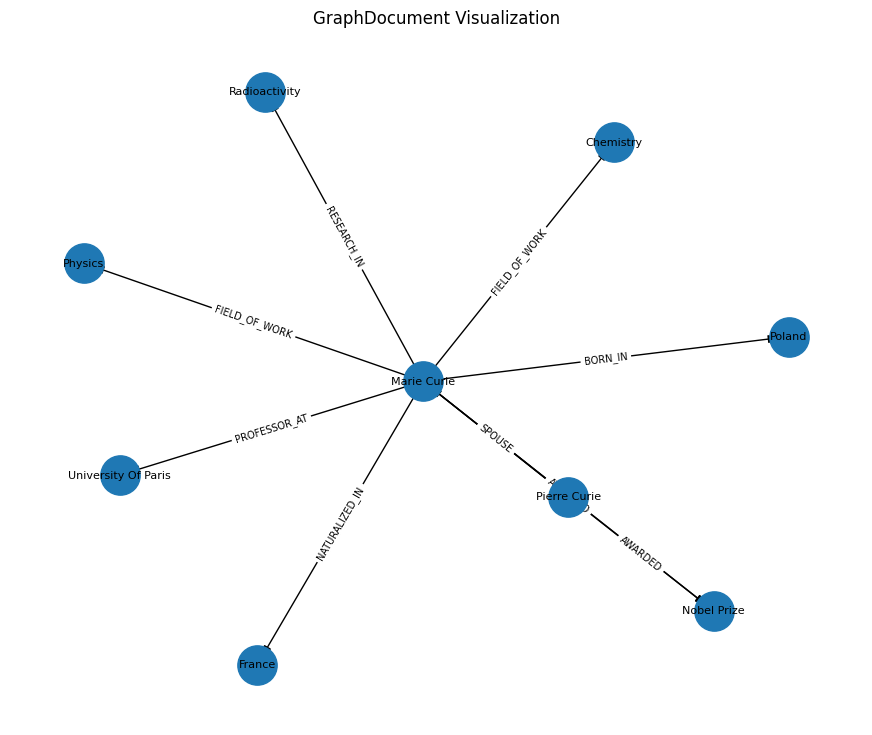

In [18]:
import matplotlib.pyplot as plt
import networkx as nx

def graphdocument_to_nx(graph_document):
    G = nx.DiGraph()

    for n in graph_document.nodes:
        G.add_node(n.id, type=getattr(n, "type", None), **(getattr(n, "properties", {}) or {}))

    for r in graph_document.relationships:
        src = getattr(r.source, "id", r.source)
        dst = getattr(r.target, "id", r.target)
        rel_type = getattr(r, "type", None)
        G.add_edge(src, dst, type=rel_type)
    return G

gd = graph_documents[0]
G = graphdocument_to_nx(gd)

plt.figure(figsize=(11, 9))
pos = nx.spring_layout(G, seed=42)      
nx.draw_networkx_nodes(G, pos, node_size=800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=12)
nx.draw_networkx_labels(G, pos, font_size=8)

edge_labels = nx.get_edge_attributes(G, 'type')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.axis('off')
plt.title("GraphDocument Visualization")
plt.show()

그러나 어떤 속성이 생길지 알 수 없고 불필요하게 많은 속성은 오히려 성능을 나쁘게 만들 수 있습니다.

사용하고자 하는 상황에 맞게 그래프의 노드와 엣지의 속성을 제한해줍니다.

In [19]:
llm_transformer_filtered = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=["Person", "Country", "Organization"],
    allowed_relationships=["NATIONALITY", "LOCATED_IN", "WORKED_AT", "SPOUSE"],
)
graph_documents_filtered = llm_transformer_filtered.convert_to_graph_documents(
    documents
)

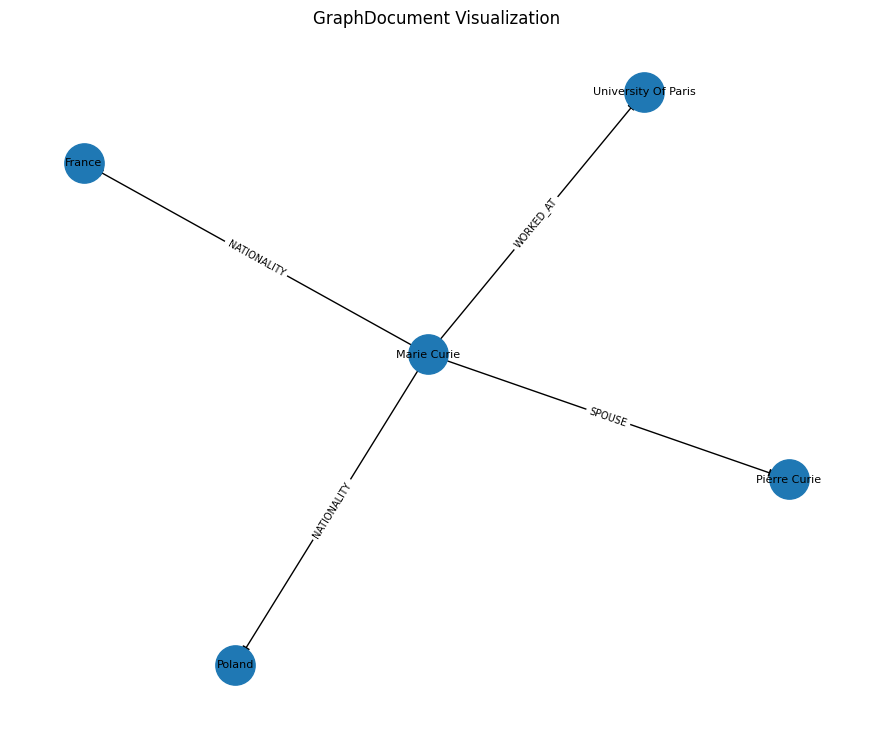

In [20]:
gd = graph_documents_filtered[0]
G = graphdocument_to_nx(gd)

plt.figure(figsize=(11, 9))
pos = nx.spring_layout(G, seed=42)      
nx.draw_networkx_nodes(G, pos, node_size=800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=12)
nx.draw_networkx_labels(G, pos, font_size=8)

edge_labels = nx.get_edge_attributes(G, 'type')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.axis('off')
plt.title("GraphDocument Visualization")
plt.show()

위의 작업은 엔티티가 추출된 Document입니다. 
이것을 실제로 그래프로 만들어주기 위해 NetworkxEntityGraph를 사용합니다.

In [21]:
graph = NetworkxEntityGraph()

for node in graph_documents_filtered[0].nodes:
    graph.add_node(node.id) #노드를 추가

for edge in graph_documents_filtered[0].relationships:
    graph._graph.add_edge(
            edge.source.id, #소스 노드의 ID
            edge.target.id, #타겟 노드의 ID
            relation=edge.type, #엣지의 타입
        )

랭체인은 그래프 검색을 위한 GraphQAChain을 제공합니다. 

1. 사용자의 질문을 입력받음 (예: “Marie Curie가가 누구야?”)
2. LLM이 질문에서 엔티티 추출 (→ “Marie Curie”)
3. 그래프에서 해당 노드의 주변 관계 검색 
4. 관련 트리플(context)들을 LLM에 전달 - (Marie Curie, SPOUSE, Pierre Curie) 
5. LLM이 context 기반으로 최종 답변 생성

In [22]:
chain = GraphQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True
)

In [23]:
question = "Marie Curie가 누구야?"
chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
Marie Curie
Full Context:
Marie Curie NATIONALITY Poland
Marie Curie NATIONALITY France
Marie Curie SPOUSE Pierre Curie
Marie Curie WORKED_AT University Of Paris

> Finished chain.


'Marie Curie는 폴란드와 프랑스 국적을 가진 과학자로, 피에르 퀴리와 결혼했으며 파리 대학에서 일했습니다.'

하나의 코드로 묶어서 봅시다.

In [24]:
from langchain_core.documents import Document
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain.chains import GraphQAChain
from langchain.graphs import NetworkxEntityGraph

text = """
Marie Curie, born in 1867, was a Polish and naturalised-French physicist and chemist who conducted pioneering research on radioactivity.
She was the first woman to win a Nobel Prize, the first person to win a Nobel Prize twice, and the only person to win a Nobel Prize in two scientific fields.
Her husband, Pierre Curie, was a co-winner of her first Nobel Prize, making them the first-ever married couple to win the Nobel Prize and launching the Curie family legacy of five Nobel Prizes.
She was, in 1906, the first woman to become a professor at the University of Paris. 
"""

documents = [Document(page_content=text)]
llm_transformer = LLMGraphTransformer(llm=llm)
graph_documents = llm_transformer.convert_to_graph_documents(documents)

llm_transformer_filtered = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=["Person", "Country", "Organization"],
    allowed_relationships=["NATIONALITY", "LOCATED_IN", "WORKED_AT", "SPOUSE"],
)
graph_documents_filtered = llm_transformer_filtered.convert_to_graph_documents(
    documents
)

graph = NetworkxEntityGraph()

for node in graph_documents_filtered[0].nodes:
    graph.add_node(node.id)

for edge in graph_documents_filtered[0].relationships:
    graph._graph.add_edge(
            edge.source.id,
            edge.target.id,
            relation=edge.type,
        )

chain = GraphQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True
)

chain.run("Marie Curie가 누구야?")



> Entering new GraphQAChain chain...
Entities Extracted:
Marie Curie
Full Context:
Marie Curie NATIONALITY Poland
Marie Curie NATIONALITY France
Marie Curie SPOUSE Pierre Curie
Marie Curie WORKED_AT University Of Paris

> Finished chain.


'Marie Curie는 폴란드와 프랑스 국적을 가진 과학자이며, 피에르 퀴리와 결혼했습니다. 그녀는 파리 대학교에서 일했습니다.'

## graph RAG를 사용한 기업 정보 답변기

위키피디아 https://en.wikipedia.org/wiki/Portal:Companies/Index_by_industry 기업 정보 페이지에 들어가면 다양한 분야의 기업들이 정리되어 있습니다.

여기에서 통신(Telecommunications) 관련 기업들의 정보를 모아 답변해주는 RAG를 만들어보겠습니다.

In [ ]:
import os
from urllib.parse import quote

from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter, MarkdownHeaderTextSplitter

from langchain_community.document_loaders import AsyncHtmlLoader
from langchain_community.document_transformers import Html2TextTransformer

from langchain_community.document_loaders import WikipediaLoader

from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain.graphs import NetworkxEntityGraph
from langchain.chains.graph_qa.base import GraphQAChain

titles = [ #양이 많아 몇 개만 추려서 사용합니다.
    "KT_Corporation", 
    "AT&T", "Avaya", "Qwest", "Sprint_Corporation"
    "China_Mobile", "China_Telecom",
    "KDDI", "Nippon_Telegraph_and_Telephone",
]

def build_urls_from_titles(ts):
    return [f"https://en.wikipedia.org/wiki/{quote(t.replace(' ', '_'))}" for t in ts]

def load_docs_html(urls):
    loader = AsyncHtmlLoader(urls, verify_ssl=True, encoding="utf-8")
    html_docs = loader.load()
    html2text = Html2TextTransformer()
    text_docs = html2text.transform_documents(html_docs)
    return text_docs

def load_docs_wikipedia_api(ts):
    out = []
    for t in ts:
        try:    
            w = WikipediaLoader(query=t, load_max_docs=1, lang="en")
            d = w.load()
            out.extend(d)
        except Exception as e:
            print(f"[warn] WikipediaLoader failed for {t}: {e}")
    return out

urls = build_urls_from_titles(titles)
docs = load_docs_html(urls)

docs = [d if isinstance(d, Document) else Document(page_content=str(d)) for d in docs] #<-- 문자열이면 Document로 변환해주기

splitter = CharacterTextSplitter(
    chunk_size=250, chunk_overlap=20,
)
splits = splitter.split_documents(docs)
print(f"[info] loaded docs: {len(docs)}, splits: {len(splits)}")

USER_AGENT environment variable not set, consider setting it to identify your requests.
Fetching pages: 100%|##########| 8/8 [00:02<00:00,  3.09it/s]
Created a chunk of size 690, which is longer than the specified 250
Created a chunk of size 949, which is longer than the specified 250
Created a chunk of size 1523, which is longer than the specified 250
Created a chunk of size 532, which is longer than the specified 250
Created a chunk of size 1010, which is longer than the specified 250
Created a chunk of size 1222, which is longer than the specified 250
Created a chunk of size 1711, which is longer than the specified 250
Created a chunk of size 4007, which is longer than the specified 250
Created a chunk of size 802, which is longer than the specified 250
Created a chunk of size 806, which is longer than the specified 250
Created a chunk of size 252, which is longer than the specified 250
Created a chunk of size 347, which is longer than the specified 250
Created a chunk of size 342, 

[info] loaded docs: 8, splits: 656


In [26]:
transformer = LLMGraphTransformer(
    llm=llm,
    # allowed_nodes=[],
    # allowed_relationships=[],
)

import asyncio
from itertools import islice

def batched(iterable, n):
    it = iter(iterable)
    while True:
        chunk = list(islice(it, n))
        if not chunk: break
        yield chunk

BATCH_SIZE = 16      # 한 요청당 split 개수
MAX_CONCURRENCY = 4  # 동시에 날릴 배치 개수(요금/TPM 제한에 맞춰)

async def process_batch(batch):
    return await transformer.aconvert_to_graph_documents(batch)

from tqdm import tqdm
async def main_async():
    tasks, results = [], []
    sem = asyncio.Semaphore(MAX_CONCURRENCY)

    async def worker(b):
        async with sem:
            return await process_batch(b)

    batches = list(batched(splits, BATCH_SIZE))
    for b in batches:
        tasks.append(asyncio.create_task(worker(b)))

    for i, t in tqdm(enumerate(asyncio.as_completed(tasks), 1), total=len(batches)):
        gds = await t
        results.extend(gds)

    return results

all_graph_docs = await main_async()

for doc in all_graph_docs[:10]:
    for node in doc.nodes:
        print(node)

print('==============================')

for doc in all_graph_docs[:10]:
    for edge in doc.relationships:
        print(edge)

 98%|█████████▊| 40/41 [04:15<00:32, 32.57s/it]


In [27]:
graph = NetworkxEntityGraph()
node_types = set()
edge_types = set()

def to_id(x):
    return getattr(x, "id", x)

for gd in all_graph_docs:
    # 노드
    for n in gd.nodes:
        nid = str(to_id(n))
        graph.add_node(nid)
        node_types.add(n.type)
    # 엣지
    for r in gd.relationships:
        src = str(to_id(r.source))
        tgt = str(to_id(r.target))
        rel = getattr(r, "type", "RELATED_TO")
        graph._graph.add_edge(src, tgt, relation=rel)
        edge_types.add(r.type)

graph._graph = graph._graph.to_undirected()

print(f"[info] 노드 수: {len(graph._graph.nodes)}, 엣지 수: {len(graph._graph.edges)}")
print(f"[info] 노드 타입 수: {len(node_types)}, 엣지 타입 수: {len(edge_types)}")
print(f"노드 종류 : {list(node_types)[:30]}")
print(f"엣지 종류 : {list(edge_types)[:30]}")

[info] 노드 수: 4112, 엣지 수: 3621
[info] 노드 타입 수: 181, 엣지 타입 수: 1102
노드 종류 : ['Conceptual entity', 'Sports league', 'Data', 'Monument', 'Fact', 'Phone model', 'Cable system', 'Date', 'Business', 'Product', 'Tool', 'Rocket', 'Group', 'Product line', 'Measurement', 'Policy', 'Thing', 'Vehicle', 'Generation', 'Stock', 'Position', 'Network', 'User group', 'Index', 'Equipment', 'Legalcase', 'List', 'Quantitativeentity', 'City', 'Protocol']
엣지 종류 : ['RENAMED_AS', 'PART_OF_INDEX', 'REDIRECTS_TO', 'CONTRACTED_WITH', 'CLAIMS_HISTORY_OF', 'FORMATION_DATE', 'PUBLIC_OFFERING', 'HAS_SUBSIDIARY', 'ESTABLISHED_SUBSIDIARIES_IN', 'OWNERSHIP_SHARE_49.5%', 'DATE', 'PARTNERED_WITH', 'FORMER_HEADQUARTERS', 'PAYMENT', 'DELISTED_FROM', 'UNIFIED_PLATFORM', 'ACQUIRED_MANAGERIAL_RIGHTS_OF_IN_DATE', 'HAS_SUBSECTION', 'FORMED', 'RENAMED_ON', 'CONFIRMED_ON_DATE', 'DECISION_DATE', 'IN_SOURCE', 'REBRANDED_IN_YEAR', 'COMPLETED_RESTRUCTURING_ON', 'OWNED', 'APPLIED_PUBLIC_CORPORATION_ACT_ON', 'DEFUNCT', 'PROMOTED_AS', 'OPP

In [28]:
graph_chain = GraphQAChain.from_llm(
    llm=llm,
    graph=graph,
    verbose=True,
)

print(graph_chain.invoke({"query": "Kt의 창립일은 언제야?"})["result"])



> Entering new GraphQAChain chain...
Entities Extracted:
NONE
Full Context:


> Finished chain.
도움을 드리기 위해 관련된 지식 삼중항이 필요합니다. 질문에 대한 답을 제공할 수 있도록 "Kt의 창립일"에 관한 정보를 주시면 감사하겠습니다.


아래는 graph chain의 내부에 있는 프롬프트를 복사한 것입니다.
해당 프롬프트를 보면 어떻게 동작하는지, 어떤 한계가 있는지 생각해 볼 수 있습니다.

이 기본 프롬프트를 사용하는게 아니라 약간 개선하여 그래프 RAG의 성능을 높여봅시다.


```python
qa_prompt:   = PromptTemplate(input_variables=['context', 'question'], 
                input_types={}, partial_variables={}, 
                template="""Use the following knowledge triplets to answer the question at the end. 
                If you don't know the answer, just say that you don't know, don't try to make up an answer.
                \n\n{context}\n\nQuestion: {question}\nHelpful Answer:""")

entity_prompt: = PromptTemplate(
    input_variables=['input'],input_types={}, partial_variables={}, 
template="""Extract all entities from the following text. As a guideline, a proper noun is generally capitalized. 
You should definitely extract all names and places.\n\nReturn the output as a single comma-separated list, or NONE if there is nothing of note to return.
\n\nEXAMPLE\ni'm trying to improve Langchain's interfaces, the UX, its integrations with various products the user might want ... a lot of stuff.
\nOutput: Langchain\nEND OF EXAMPLE\n\nEXAMPLE\ni'm trying to improve Langchain's interfaces, the UX, its integrations 
with various products the user might want ... a lot of stuff. 
I'm working with Sam.\nOutput: Langchain, Sam\nEND OF EXAMPLE\n\nBegin!\n\n{input}\nOutput:"""),
```


In [29]:
from langchain.prompts import PromptTemplate

candidate_entities = list(graph._graph.nodes)

ENTITY_PROMPT_KO = PromptTemplate(
    input_variables=["input", "entities"],
    template="""다음 질문에 답하려면 아래 '그래프 엔티티 후보' 중에서 관련된 엔티티 이름을 1~5개 고르세요.
- 정확히 '엔티티 이름'만 쉼표로 출력하세요.
- 후보에 없으면 고르지 마세요.

[그래프 엔티티 후보]
{entities}

[질문]
{input}

[정답](쉼표로 구분된 엔티티들만):"""
)

QA_PROMPT_KO = PromptTemplate(
    input_variables=["question", "context"],
    template="""당신은 지식그래프 QA 어시스턴트입니다.
주어진 엔티티 주변 트리플을 근거로 한국어로 간결하게 답하세요.
관련 근거의 레퍼런스를 트리플 형태로 같이 제시하세요.
그래프와 컨텍스트에서 찾을 수 없다면 관련 근거가 없다고 말하세요.

형식 : [node1] → [edge] → [node2]

[질문]
{question}

[컨텍스트]
{context}

[답변]"""
)

graph_chain = GraphQAChain.from_llm(
    llm=llm,
    graph=graph,
    entity_prompt=ENTITY_PROMPT_KO.partial(entities="\n".join(map(str, candidate_entities))),
    qa_prompt=QA_PROMPT_KO,
    verbose=True,
)

In [ ]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,     
    api_version="2024-12-01-preview",
    # temperature=0.1, # GPT5를 쓰는 경우 temp 삭제 
)

In [30]:
print(graph_chain.invoke({"query": "케이티의 창립일은 언제야?"})["result"])



> Entering new GraphQAChain chain...
Entities Extracted:
1981
Full Context:
1981 FOUNDED_IN Kt

> Finished chain.
케이티의 창립일은 1981년입니다.

[근거]  
1981 → FOUNDED_IN → Kt


In [31]:
graph_chain.verbose = False

query_list = [
    "Kt의 주요 사업은 뭐야?",
    "Kt는 어디에 위치해 있어?",
    "2009년에 각 통신사들에는 어떤 일이 있었어?",
    "미국의 통신사는 어떤 곳이 있어?",
    "일본의 두 통신사를 비교해줘",
    ""
]

for idx, query in enumerate(query_list):
    print(f"{idx+1}. [{query}]")
    print(f"답변 : {graph_chain.invoke({'query': query})['result']}")
    print("-"*100)

1. [Kt의 주요 사업은 뭐야?]
답변 : Kt의 주요 사업은 이동통신 서비스(Voice Services, 4G LTE, Mobile Wimax, Wibro Network), 네트워크 인프라 구축(Backbone Telecommunication Network, Giga Wire Technology), 위성 운영(Koreasat Fleet Of Satellites), 모바일 및 인터넷 서비스 제공(Mobile TV, Show Broadband Services, Ucloud), 그리고 5G 기술 시험 및 상용화 등이다.

[관련 근거]
- Kt → OFFER → Giga Lte  
- Kt → PLANS_TO_EXPAND_BEYOND_IN_SECOND_HALF_OF_2011 → Voice Services  
- Kt → SIGNED_CONTRACT_TO_BUILD → Mobile Wimax Network  
- Kt → SIGNED_CONTRACT_TO_BUILD → Wibro Network  
- Kt → SIGNED_DEAL_TO_BUILD_BACKBONE → Telecommunication Network  
- Kt → PROVIDE → Giga Wire Technology  
- Kt → OPERATE → Koreasat Fleet Of Satellites  
- Kt → LAUNCHED → Mobile Tv  
- Kt → LAUNCHED → Show Broadband Services  
- Kt → LAUNCHED → Ucloud  
- Kt → TEST_TECHNOLOGY → 5G Technologies  
- Kt → COMMERCIALIZED → 5G Standalone (5G Sa) Technology
----------------------------------------------------------------------------------------------------
2. [Kt는 어디에 위치해 있어?]
답변 : Kt는 서울에 위치